# State Farm Distracted Driver Detection — MobileNetV3 Transfer Learning (PyTorch)

This notebook trains a **MobileNetV3** classifier on the **State Farm Distracted Driver Detection** dataset using **PyTorch + TorchVision** transfer learning, with a **driver/subject-level split** to reduce leakage.

**Classes (Kaggle):**
- `c0`: safe driving
- `c1`: texting - right
- `c2`: talking on the phone - right
- `c3`: texting - left
- `c4`: talking on the phone - left
- `c5`: operating the radio
- `c6`: drinking
- `c7`: reaching behind
- `c8`: hair and makeup
- `c9`: talking to passenger

> Tip: This notebook is written to be robust for **RTX 50-series (Blackwell / sm_120)** by checking GPU compatibility and using a modern PyTorch build.


## 0) Install pytorch and CUDA GPU support

In [146]:
#Run this in powershell OR if running in notebook, restart kernel after install

%pip install -U pip setuptools wheel

#pytorch, torchvision
#NOTE: the '+cu130' part is important for NVIDIA CUDA 13 gpu compatibility
%pip install torch==2.9.1+cu130 torchvision==0.24.1+cu130 --index-url https://download.pytorch.org/whl/cu130

#If cu130 isn't available for you system use cu128 instead

Note: you may need to restart the kernel to use updated packages.
Looking in indexes: https://download.pytorch.org/whl/cu130
Note: you may need to restart the kernel to use updated packages.


### Install the rest of the training stack


In [147]:
#other stuff
%pip install numpy==2.4.1 pandas==2.3.3 scikit-learn==1.8.0 pillow==12.1.0 tqdm==4.67.1 matplotlib==3.10.8


Note: you may need to restart the kernel to use updated packages.


## 1) Imports, config

In [148]:
import os
from pathlib import Path
import random
import math
import time
import json

import numpy as np
import pandas as pd

from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from torchvision import transforms
from torchvision.transforms import InterpolationMode
from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights


## 2) GPU and CUDA chekcs

- CUDA availability
- device name
- compute capability (sm version)
- torch/torchvision versions


In [149]:
def cuda_sanity_check():
    print("torch:", torch.__version__)
    try:
        import torchvision
        print("torchvision:", torchvision.__version__)
    except Exception as e:
        print("torchvision import failed:", e)

    print("torch.version.cuda:", torch.version.cuda)
    print("CUDA available:", torch.cuda.is_available())

    if torch.cuda.is_available():
        idx = torch.cuda.current_device()
        props = torch.cuda.get_device_properties(idx)
        print("GPU:", props.name)
        print("Compute capability:", f"sm_{props.major}{props.minor}")
        print("Total VRAM (GB):", round(props.total_memory / (1024**3), 2))
        #make a random tensor to test kernel
        x = torch.randn(1024, 1024, device="cuda")
        y = x @ x
        print("Matmul OK. Mean:", float(y.mean()))
    else:
        print("No CUDA GPU detected, fall back to CPU.")

cuda_sanity_check()


torch: 2.9.1+cu130
torchvision: 0.24.1+cu130
torch.version.cuda: 13.0
CUDA available: True
GPU: NVIDIA GeForce RTX 5070
Compute capability: sm_120
Total VRAM (GB): 11.94
Matmul OK. Mean: -0.03658275306224823


## 3) Dataset (statefarm from kaggle)
https://www.kaggle.com/datasets/rightway11/state-farm-distracted-driver-detection

Expected layout

```
state_farm/
  driver_imgs_list.csv
  imgs/
    train/
      c0/....
      c1/....
      ...
      c9/....
    test/...
```


In [150]:
#dataset folder
DATA_ROOT = Path(r"../Datasets/statefarm")  

CSV_PATH = DATA_ROOT / "driver_imgs_list.csv"
TRAIN_DIR = DATA_ROOT / "imgs" / "train"

assert CSV_PATH.exists(), f"Missing {CSV_PATH}"
assert TRAIN_DIR.exists(), f"Missing {TRAIN_DIR}. Expected imgs/train/c0..c9"
print("Found:", CSV_PATH)
print("Found:", TRAIN_DIR)


Found: ../Datasets/statefarm/driver_imgs_list.csv
Found: ../Datasets/statefarm/imgs/train


## 4) Build a driver/subject level train/val split (prevents leakage)

split by **`subject`** column from `driver_imgs_list.csv`.


In [151]:
df = pd.read_csv(CSV_PATH)
df.head()


,subject,classname,img
0,p012,c0,img_10206.jpg
1,p012,c0,img_27079.jpg
2,p012,c0,img_50749.jpg
3,p012,c0,img_97089.jpg
4,p012,c0,img_37741.jpg


In [152]:
#more checks
required_cols = {"subject", "classname", "img"}
missing = required_cols - set(df.columns)
assert not missing, f"CSV missing columns: {missing}"

df["path"] = df.apply(lambda r: TRAIN_DIR / r["classname"] / r["img"], axis=1)
missing_files = (~df["path"].apply(lambda p: p.exists())).sum()
assert missing_files == 0, f"Some image paths are missing ({missing_files}). Check your folder structure."

classes = sorted(df["classname"].unique())
class_to_idx = {c:i for i,c in enumerate(classes)}
idx_to_class = {i:c for c,i in class_to_idx.items()}

print("Classes:", classes)
print("Num images:", len(df))
print("Num subjects:", df["subject"].nunique())


Classes: ['c0', 'c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8', 'c9']
Num images: 34924
Num subjects: 20


In [153]:
#keeps all images for a subject either in train or val to prevent leakage
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(df, groups=df["subject"]))

train_df = df.iloc[train_idx].reset_index(drop=True)
val_df   = df.iloc[val_idx].reset_index(drop=True)

print("Train:", len(train_df), "Val:", len(val_df))
print("Train subjects:", train_df["subject"].nunique(), "Val subjects:", val_df["subject"].nunique())


Train: 27872 Val: 7052
Train subjects: 16 Val subjects: 4


## 5) Transforms (MobileNetV3 defaults + augmentation)

official ImageNet normalization from the MobileNetV3 weights metadata.


In [154]:
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from torchvision.models import MobileNet_V3_Large_Weights

weights = MobileNet_V3_Large_Weights.DEFAULT

#use official preprocessing pipeline attached the weights
preprocess = weights.transforms()

#get mean and std or else fallback
mean = getattr(preprocess, "mean", None) or weights.meta.get("mean", [0.485, 0.456, 0.406])
std  = getattr(preprocess, "std", None)  or weights.meta.get("std",  [0.229, 0.224, 0.225])

crop_size = getattr(preprocess, "crop_size", (224, 224))
#IMG_SIZE = crop_size[0] if isinstance(crop_size, (tuple, list)) else int(crop_size)

IMG_SIZE = 256 #made this bigger to learn features better

train_tfms = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5), #randomly flip half the images

    #resize larger and take a random square crop
    transforms.Resize(int(IMG_SIZE * 1.15)), #slightly bigger 
    transforms.RandomCrop(IMG_SIZE), #crop to 256
    
    transforms.TrivialAugmentWide(interpolation=InterpolationMode.BILINEAR),
    
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
    
    #RandomErasing helps prevent overfitting to specific car interiors 
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15)),
])

val_tfms = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.15)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std),
])

#use mobilenet weight preprocessing
val_tfms = preprocess

print("IMG_SIZE:", IMG_SIZE)
print("mean:", mean, "std:", std)


IMG_SIZE: 256
mean: [0.485, 0.456, 0.406] std: [0.229, 0.224, 0.225]


## 6) Dataset / DataLoaders


In [155]:
class StateFarmCSVDataset(Dataset):
    def __init__(self, frame, class_to_idx, transform=None, cache_images=False):
        self.frame = frame.reset_index(drop=True)
        self.class_to_idx = class_to_idx
        self.transform = transform
        self.cache_images = cache_images
        self._cache = {} 

    def __len__(self):
        return len(self.frame)

    def _load_image(self, i):
        if self.cache_images and i in self._cache:
            return self._cache[i].copy() 

        img_path = self.frame.loc[i, "path"]
        im = Image.open(img_path).convert("RGB")

        if self.cache_images:
            self._cache[i] = im.copy()

        return im

    def __getitem__(self, i):
        row = self.frame.loc[i]
        y = self.class_to_idx[row["classname"]]
        im = self._load_image(i)
        x = self.transform(im) if self.transform else transforms.ToTensor()(im)
        return x, y

train_ds = StateFarmCSVDataset(train_df, class_to_idx, transform=train_tfms, cache_images=False)
val_ds   = StateFarmCSVDataset(val_df, class_to_idx, transform=val_tfms,   cache_images=False)

BATCH_SIZE = 128
NUM_WORKERS = 8

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True, 
    persistent_workers=True,  
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=False,
    persistent_workers=True,
)


print("NUM_WORKERS:", NUM_WORKERS)


NUM_WORKERS: 8


In [156]:
import time
t0 = time.time()
xb, yb = next(iter(train_loader))
print("Got batch:", xb.shape, yb.shape, "in", round(time.time()-t0, 2), "sec")


Got batch: torch.Size([128, 3, 256, 256]) torch.Size([128]) in 0.69 sec


## 7) Model: MobileNetV3-Large transfer learning


In [ ]:
import torch
import torch.nn as nn
from torchvision.models import mobilenet_v3_large, MobileNet_V3_Large_Weights

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#mobilenetV3 weights
weights = MobileNet_V3_Large_Weights.DEFAULT
model = mobilenet_v3_large(weights=weights)

num_classes = len(classes)

last_channel = model.classifier[-1].in_features
model.classifier[-1] = nn.Sequential(
    nn.Linear(last_channel, 1280),
    nn.Hardswish(),
    nn.Dropout(p=0.4), #increased from default 0.2 to 0.4 to counter overfitting
    nn.Linear(1280, num_classes)
)

#freeze most of the network, unfreeze last few blocks

#1) Freeze everything first (dont change weights or gradients)
for p in model.parameters():
    p.requires_grad = False

#2) unfreeze last classifier layer
for p in model.classifier.parameters():
    p.requires_grad = True

#3) Unfreeze last N blocks of feature extractor
#helps model adapt higher level features to dataset.
UNFREEZE_LAST_N_BLOCKS = 6  #dont put this too high or else overfit

#convert to list to slice the last N blocks
feature_blocks = list(model.features.children())

#unfreeze last N feature blocks
for block in feature_blocks[-UNFREEZE_LAST_N_BLOCKS:]:
    for p in block.parameters():
        p.requires_grad = True

#move model onto device (GPU or CPu)
model = model.to(device)

#performance tweaks
if device.type == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass

#print out frozen and unfrozen layers
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

print("Unfroze last", UNFREEZE_LAST_N_BLOCKS, "feature blocks + classifier.")


Trainable params: 5,793,402 / 5,854,522 (98.96%)
Unfroze last 10 feature blocks + classifier.


## 8) Training utilities (AMP + metrics + checkpointing)


In [158]:
from dataclasses import dataclass

@dataclass
class TrainConfig:
    epochs: int = 25
    lr: float = 5e-4
    weight_decay: float = 1e-2
    label_smoothing: float = 0.02
    grad_clip: float = 1.0

    #early stopping config
    patience: int = 8 #wait 8 epochs without improvement before stopping
    min_delta: float = 0.002   #track actual imrprovement and not random variation

    out_dir: Path = Path("./checkpoints")
    best_name: str = "mobilenetv3_statefarm_best.pt"


cfg = TrainConfig()
cfg.out_dir.mkdir(parents=True, exist_ok=True)
print(cfg)


TrainConfig(epochs=25, lr=0.0005, weight_decay=0.01, label_smoothing=0.02, grad_clip=1.0, patience=8, min_delta=0.002, out_dir=PosixPath('checkpoints'), best_name='mobilenetv3_statefarm_best.pt')


In [159]:
criterion = nn.CrossEntropyLoss(label_smoothing=cfg.label_smoothing)

#optimize parameters that are unfrozen
feature_params = []
head_params = []

for name, p in model.named_parameters():
    if not p.requires_grad:
        continue
    if name.startswith("classifier"):
        head_params.append(p)
    else:
        feature_params.append(p)

optimizer = torch.optim.AdamW(
    [
        {"params": feature_params, "lr": cfg.lr * 0.2}, #smaller LR for backbone, dont need big adjustments
        {"params": head_params, "lr": cfg.lr}, #bigger LR for classifier layer
    ],
    weight_decay=cfg.weight_decay
)

#reduce LR when val_f1 stops improving 
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max", #maximize val_f1
    factor=0.2, #multiply LR to decrease
    patience=2, #wait 2 epochs before reducing
    min_lr=1e-6,
)

def get_lrs(opt):
    return [pg["lr"] for pg in opt.param_groups]

#AMP scaler for performance
scaler = torch.amp.GradScaler(enabled=(device.type == "cuda"))

def run_one_epoch(model, loader, train: bool):
    model.train(train)
    all_y = []
    all_p = []
    total_loss = 0.0

    pbar = tqdm(loader, desc="train" if train else "val", leave=False)
    for xb, yb in pbar:
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)

        with torch.set_grad_enabled(train):
            with torch.autocast(device_type=device.type, dtype=torch.float16, enabled=(device.type == "cuda")):
                logits = model(xb)
                loss = criterion(logits, yb)

            if train:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()

                if cfg.grad_clip is not None and cfg.grad_clip > 0:
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)

                scaler.step(optimizer)
                scaler.update()

        total_loss += float(loss.item()) * xb.size(0)

        preds = logits.argmax(dim=1)
        all_y.append(yb.detach().cpu().numpy())
        all_p.append(preds.detach().cpu().numpy())

        pbar.set_postfix(loss=float(loss.item()))

    y_true = np.concatenate(all_y)
    y_pred = np.concatenate(all_p)
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")
    return avg_loss, acc, f1

def save_checkpoint(path: Path, model):
    torch.save(model.state_dict(), path)

    meta = {
        "classes": classes,
        "class_to_idx": class_to_idx,
        "img_size": IMG_SIZE,
        "mean": mean,
        "std": std,
        "torch_version": str(torch.__version__), 
    }
    with open(path.with_suffix(".json"), "w") as f:
        json.dump(meta, f, indent=2)


best_val_f1 = -1.0
best_epoch = -1
bad_epochs = 0

history = []


## 9) Train


In [160]:
for epoch in range(1, cfg.epochs + 1):
    t0 = time.time()
    train_loss, train_acc, train_f1 = run_one_epoch(model, train_loader, train=True)
    val_loss, val_acc, val_f1 = run_one_epoch(model, val_loader, train=False)

    before = get_lrs(optimizer)
    scheduler.step(val_f1) 
    after = get_lrs(optimizer)

    if after != before:
        print("LR reduced from", before, " to", after)


    dt = time.time() - t0
    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "train_f1": train_f1,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_f1": val_f1,
        "seconds": dt,
        "lr": optimizer.param_groups[0]["lr"],
    }
    history.append(row)

    print(
        f"Epoch {epoch:02d}/{cfg.epochs} | "
        f"train loss {train_loss:.4f} acc {train_acc:.4f} f1 {train_f1:.4f} | "
        f"val loss {val_loss:.4f} acc {val_acc:.4f} f1 {val_f1:.4f} | "
        f"{dt:.1f}s"
    )

    #checkpoint
    #save best by val f1 ratio
    if val_f1 > best_val_f1 + cfg.min_delta:
        best_val_f1 = val_f1
        best_epoch = epoch
        bad_epochs = 0
        ckpt_path = cfg.out_dir / cfg.best_name
        save_checkpoint(ckpt_path, model)
        print("saved best (val_f1):", ckpt_path)
    else:
        bad_epochs += 1
        if bad_epochs >= cfg.patience:
            print(f"early stopping (no val_f1 improvement for {cfg.patience} epochs)")
            break


print("Best epoch:", best_epoch, "Best val f1:", best_val_f1)


Epoch 01/25 | train loss 0.5548 acc 0.8632 f1 0.8625 | val loss 1.1672 acc 0.6336 f1 0.6426 | 15.2s
saved best (val_f1): checkpoints/mobilenetv3_statefarm_best.pt


Epoch 02/25 | train loss 0.2456 acc 0.9694 f1 0.9690 | val loss 0.9115 acc 0.7323 f1 0.7293 | 16.8s
saved best (val_f1): checkpoints/mobilenetv3_statefarm_best.pt


Epoch 03/25 | train loss 0.2092 acc 0.9808 f1 0.9807 | val loss 0.9430 acc 0.7184 f1 0.7147 | 14.1s


Epoch 04/25 | train loss 0.1905 acc 0.9858 f1 0.9858 | val loss 0.9931 acc 0.7297 f1 0.7148 | 16.3s


LR reduced from [0.0001, 0.0005]  to [2e-05, 0.0001]
Epoch 05/25 | train loss 0.1835 acc 0.9874 f1 0.9873 | val loss 0.9015 acc 0.7286 f1 0.7284 | 13.6s


...

Epoch 12/25 | train loss 0.1586 acc 0.9943 f1 0.9943 | val loss 0.8828 acc 0.7465 f1 0.7430 | 16.1s


Epoch 13/25 | train loss 0.1561 acc 0.9944 f1 0.9945 | val loss 0.8757 acc 0.7473 f1 0.7435 | 13.3s


LR reduced from [4.000000000000001e-06, 2e-05]  to [1e-06, 4.000000000000001e-06]
Epoch 14/25 | train loss 0.1581 acc 0.9945 f1 0.9945 | val loss 0.8763 acc 0.7476 f1 0.7431 | 16.2s


Epoch 15/25 | train loss 0.1587 acc 0.9935 f1 0.9935 | val loss 0.8771 acc 0.7476 f1 0.7434 | 13.2s


Epoch 16/25 | train loss 0.1557 acc 0.9948 f1 0.9948 | val loss 0.8738 acc 0.7487 f1 0.7445 | 16.2s
early stopping (no val_f1 improvement for 8 epochs)
Best epoch: 8 Best val f1: 0.7501321870341995


## 10) Print training results


In [161]:

hist = pd.DataFrame(history)
hist


,epoch,train_loss,train_acc,train_f1,val_loss,val_acc,val_f1,seconds,lr
0,1,0.554794,0.863196,0.862515,1.167158,0.633579,0.642645,15.209915,0.000100
1,2,0.245634,0.969396,0.969033,0.911475,0.732275,0.729252,16.788393,0.000100
2,3,0.209239,0.980805,0.980725,0.943026,0.718378,0.714651,14.086061,0.000100
3,4,0.190527,0.985792,0.985814,0.993108,0.729722,0.714759,16.264667,0.000100
4,5,0.183523,0.987443,0.987320,0.901511,0.728588,0.728412,13.641619,0.000020
5,6,0.171947,0.989954,0.989901,0.862934,0.739648,0.738666,16.153189,0.000020
6,7,0.164879,0.992286,0.992274,0.898952,0.736245,0.733845,13.321015,0.000020
7,8,0.163213,0.993183,0.993203,0.848628,0.756665,0.750132,16.121887,0.000020
8,9,0.163782,0.992609,0.992522,0.899878,0.735111,0.731853,13.216850,0.000020
9,10,0.161188,0.993398,0.993365,0.860699,0.747873,0.744062,16.083176,0.000020


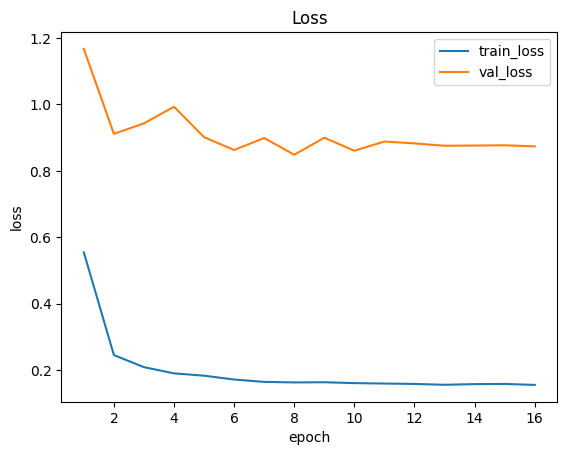

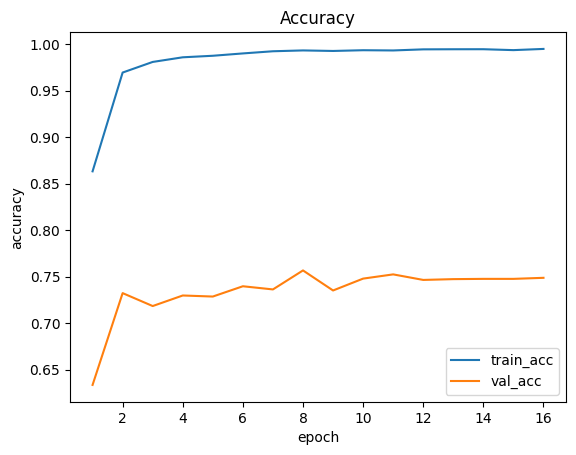

In [162]:
plt.figure()
plt.plot(hist["epoch"], hist["train_loss"], label="train_loss")
plt.plot(hist["epoch"], hist["val_loss"], label="val_loss")
plt.legend()
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Loss")
plt.show()

plt.figure()
plt.plot(hist["epoch"], hist["train_acc"], label="train_acc")
plt.plot(hist["epoch"], hist["val_acc"], label="val_acc")
plt.legend()
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("Accuracy")
plt.show()


## 11) Detailed validation report


In [163]:
#best checkpoint
ckpt_path = cfg.out_dir / cfg.best_name

#weights
state_dict = torch.load(ckpt_path, map_location=device)

#metadata
meta_path = ckpt_path.with_suffix(".json")
with open(meta_path, "r") as f:
    meta = json.load(f)

classes_ckpt = meta["classes"]
class_to_idx_ckpt = meta["class_to_idx"]

#rebuild model
best_model = mobilenet_v3_large(weights=weights)
last_channel = best_model.classifier[-1].in_features

best_model.classifier[-1] = nn.Sequential(
    nn.Linear(last_channel, 1280),
    nn.Hardswish(),
    nn.Dropout(p=0.3),
    nn.Linear(1280, len(classes_ckpt))
)

#state dict
best_model.load_state_dict(state_dict)
best_model = best_model.to(device).eval()

print("Model loaded successfully!")

#eval
y_true_all, y_pred_all = [], []
with torch.no_grad():
    for xb, yb in tqdm(val_loader, desc="val eval"):
        xb = xb.to(device, non_blocking=True)
        logits = best_model(xb)
        preds = logits.argmax(1).cpu().numpy()
        y_pred_all.append(preds)
        y_true_all.append(yb.numpy())

y_true_all = np.concatenate(y_true_all)
y_pred_all = np.concatenate(y_pred_all)

print("Accuracy:", accuracy_score(y_true_all, y_pred_all))
print("Macro F1:", f1_score(y_true_all, y_pred_all, average="macro"))
print("\nClassification report:\n")
print(classification_report(y_true_all, y_pred_all, target_names=classes_ckpt))

Model loaded successfully!


val eval: 100%|██████████| 56/56 [00:03<00:00, 15.41it/s]

Accuracy: 0.7572319909245604
Macro F1: 0.7508260745112691

Classification report:

              precision    recall  f1-score   support

          c0       0.53      0.79      0.64       746
          c1       0.96      0.78      0.86       720
          c2       0.93      0.88      0.90       730
          c3       1.00      0.97      0.98       724
          c4       0.92      0.58      0.71       764
          c5       0.72      0.98      0.83       758
          c6       0.82      0.85      0.84       718
          c7       0.79      0.71      0.75       626
          c8       0.51      0.54      0.52       690
          c9       0.55      0.42      0.48       576

    accuracy                           0.76      7052
   macro avg       0.77      0.75      0.75      7052
weighted avg       0.78      0.76      0.76      7052



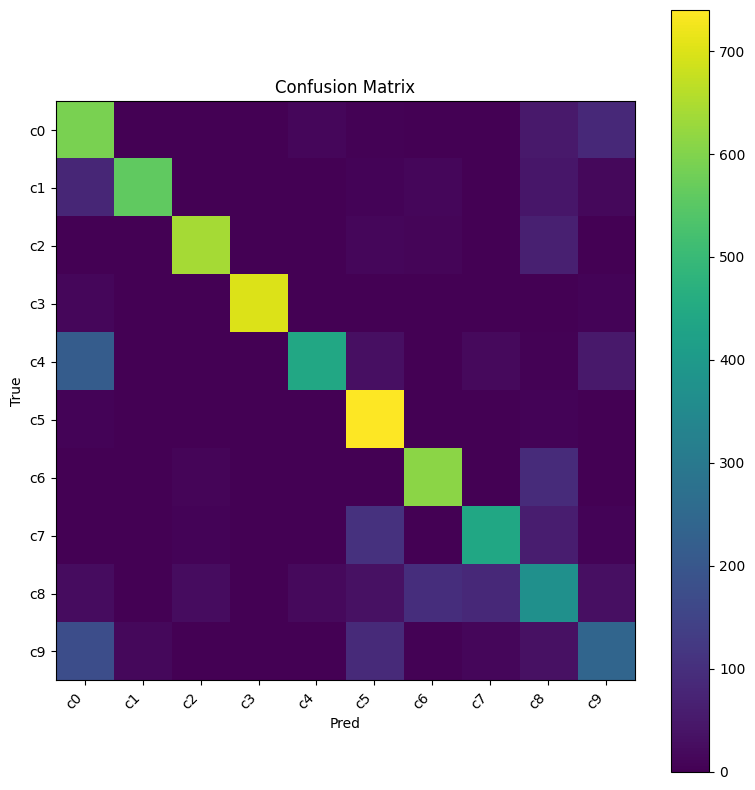

In [164]:
#confusion matrix
cm = confusion_matrix(y_true_all, y_pred_all)
plt.figure(figsize=(8, 8))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xticks(range(len(classes)), classes, rotation=45, ha="right")
plt.yticks(range(len(classes)), classes)
plt.xlabel("Pred")
plt.ylabel("True")
plt.colorbar()
plt.tight_layout()
plt.show()


## 12) Quick inference on a few images


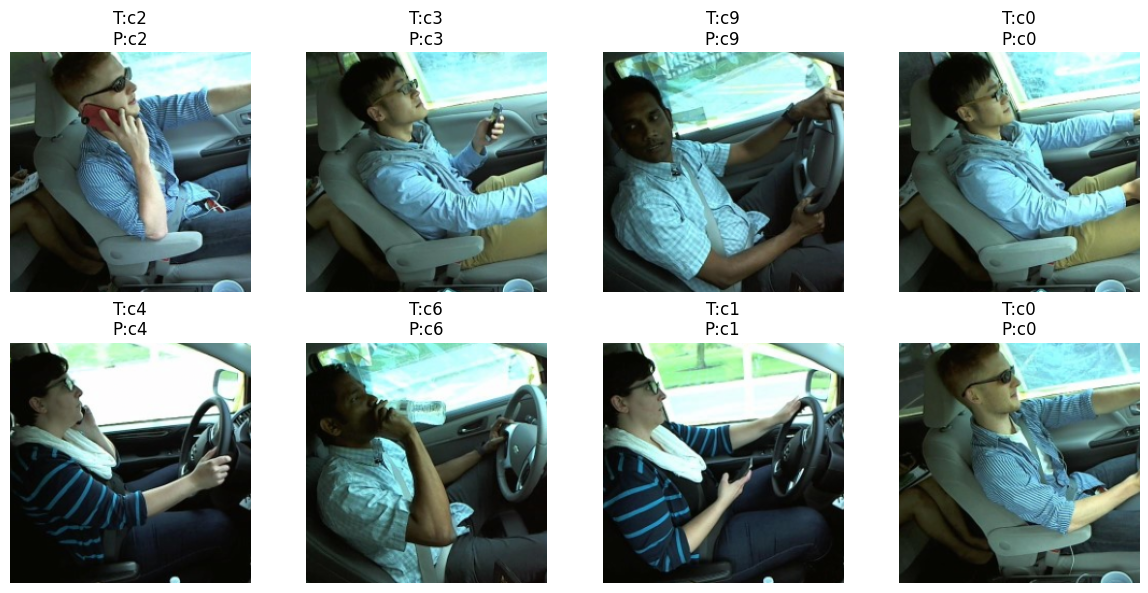

In [165]:
#test inference on some images
def denorm(x, mean, std):
    mean = torch.tensor(mean).view(3,1,1)
    std = torch.tensor(std).view(3,1,1)
    return (x * std) + mean

best_model.eval()
samples = [val_ds[i] for i in np.random.choice(len(val_ds), size=8, replace=False)]
xb = torch.stack([s[0] for s in samples]).to(device)
yb = np.array([s[1] for s in samples])

with torch.no_grad():
    logits = best_model(xb)
    probs = torch.softmax(logits, dim=1)
    pred = probs.argmax(1).cpu().numpy()

plt.figure(figsize=(12, 6))
for i in range(len(samples)):
    ax = plt.subplot(2, 4, i+1)
    img = denorm(samples[i][0].cpu(), mean, std).clamp(0,1)
    ax.imshow(img.permute(1,2,0))
    ax.axis("off")
    ax.set_title(f"T:{idx_to_class[yb[i]]}\nP:{idx_to_class[pred[i]]}")
plt.tight_layout()
plt.show()


## 13) Export (optional): TorchScript

Useful if you want to deploy the model later (e.g., to a desktop app). For mobile/on-device, you might prefer ONNX or ExecuTorch.


In [166]:
EXPORT = False

if EXPORT:
    best_model.eval()
    example = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=device)
    traced = torch.jit.trace(best_model, example)
    out_path = cfg.out_dir / "mobilenetv3_statefarm_traced.pt"
    traced.save(out_path)
    print("Saved:", out_path)


## Notes / common issues

- If you see: **“CUDA capability sm_120 is not compatible”**, you installed a PyTorch build that doesn't include Blackwell kernels. Reinstall Torch from **cu128** or **cu130**.
- If `torch.cuda.is_available()` is `False` on Windows, verify:
  - NVIDIA driver is installed and `nvidia-smi` works
  - your venv doesn't accidentally have CPU-only `torch` from PyPI
